In [21]:
# Установки (запустить один раз)
!pip install --quiet minatar gymnasium==0.28.1
!pip install --quiet torch torchvision
!pip install --quiet imageio matplotlib

In [22]:
import os
import random
import time
import pickle
from collections import deque, namedtuple
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import imageio

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Device: cpu


In [23]:
from google.colab import drive
drive.mount('/content/drive')

# Путь к проекту в Google Drive (все файлы будут сохраняться сюда)
DRIVE_PROJECT_DIR = "/content/drive/MyDrive/rl-final-project"

# Создаём структуру папок в Drive
dirs = [
    DRIVE_PROJECT_DIR,
    os.path.join(DRIVE_PROJECT_DIR, "dqn"),
    os.path.join(DRIVE_PROJECT_DIR, "imitation"),
    os.path.join(DRIVE_PROJECT_DIR, "offline_rl"),
    os.path.join(DRIVE_PROJECT_DIR, "plots"),
    os.path.join(DRIVE_PROJECT_DIR, "visuals"),
    os.path.join(DRIVE_PROJECT_DIR, "notebooks"),
]
for d in dirs:
    os.makedirs(d, exist_ok=True)

print("Project dir (Drive):", DRIVE_PROJECT_DIR)
!ls -la "{DRIVE_PROJECT_DIR}"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project dir (Drive): /content/drive/MyDrive/rl-final-project
total 47
-rw------- 1 root root 22930 Nov 21 10:25 00_setup_and_dqn.ipynb
drwx------ 2 root root  4096 Nov 21 10:19 dqn
drwx------ 2 root root  4096 Nov 21 10:19 imitation
drwx------ 2 root root  4096 Nov 21 10:19 notebooks
drwx------ 2 root root  4096 Nov 21 10:19 offline_rl
drwx------ 2 root root  4096 Nov 21 10:19 plots
drwx------ 3 root root  4096 Nov 21 10:20 visuals


In [24]:
import minatar

env = minatar.Environment("breakout")

print("state shape:", env.state_shape())
print("num actions:", env.num_actions())


state shape: [10, 10, 4]
num actions: 6


In [25]:
def state_to_numpy(state):
    arr = np.array(state, dtype=np.float32)
    return arr

def visualize_state(state, figsize=(3,3)):
    arr = state_to_numpy(state)
    if arr.ndim == 3 and arr.shape[2] > 1:
        img = np.sum(arr, axis=2)
    else:
        img = arr.squeeze()
    plt.figure(figsize=figsize)
    plt.imshow(img, cmap='gray', interpolation='nearest')
    plt.axis('off')
    plt.show()

In [26]:
def run_random_policy_and_save_frames(env, n_steps=200, save_subdir="visuals/random_breakout"):
    save_dir = os.path.join(DRIVE_PROJECT_DIR, save_subdir)
    os.makedirs(save_dir, exist_ok=True)
    frames = []

    env.reset()
    num_actions = env.num_actions()

    for t in range(n_steps):
        action = random.randrange(num_actions)
        _ = env.act(action)
        st = env.state()

        img = state_to_numpy(st)

        # Приводим к 2D
        if img.ndim == 3:
            img_show = np.sum(img, axis=2)
        else:
            img_show = img.squeeze()

        # Нормализация под NumPy 2.0
        min_val = img_show.min()
        max_val = img_show.max()
        range_val = max_val - min_val if max_val > min_val else 1.0

        img_norm = ((img_show - min_val) / range_val * 255).astype(np.uint8)

        frames.append(img_norm)

    # Сохраняем первые 20 кадров
    for i, f in enumerate(frames[:20]):
        imageio.imwrite(os.path.join(save_dir, f"frame_{i:03d}.png"), f)

    gif_path = os.path.join(save_dir, "random_agent.gif")
    imageio.mimsave(gif_path, frames[:200], fps=12)

    print("Saved random frames and gif to", save_dir)
    return gif_path

# Запуск теста случайного агента (быстрая проверка)
gif_path = run_random_policy_and_save_frames(env, n_steps=300, save_subdir="visuals/random_breakout")
gif_path



Saved random frames and gif to /content/drive/MyDrive/rl-final-project/visuals/random_breakout


'/content/drive/MyDrive/rl-final-project/visuals/random_breakout/random_agent.gif'

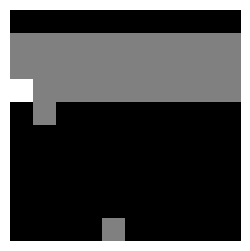

Flattened state dim: (100,)


In [27]:
def preprocess_state(state):
    arr = state_to_numpy(state)
    if arr.ndim == 3:
        arr = np.sum(arr, axis=2)
    arr = arr.astype(np.float32)
    maxv = arr.max() if arr.max() != 0 else 1.0
    arr = arr / (maxv + 1e-8)
    return arr.flatten()

# Проверяем
env.reset()
_ = env.act(0)
visualize_state(env.state())
print("Flattened state dim:", preprocess_state(env.state()).shape)

In [28]:
Transition = namedtuple('Transition', ('state', 'action', 'reward', 'next_state', 'done'))

class ReplayBuffer:
    def __init__(self, capacity):
        self.capacity = capacity
        self.buffer = deque(maxlen=capacity)
    def push(self, *args):
        self.buffer.append(Transition(*args))
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        return Transition(*zip(*batch))
    def __len__(self):
        return len(self.buffer)

class QNetworkMLP(nn.Module):
    def __init__(self, input_dim, hidden_sizes, n_actions):
        super().__init__()
        layers = []
        last = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(last, h))
            layers.append(nn.ReLU())
            last = h
        layers.append(nn.Linear(last, n_actions))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

In [34]:
def train_dqn_to_drive(env,
                       drive_dir,
                       num_steps=50000,
                       buffer_capacity=50000,
                       batch_size=64,
                       gamma=0.99,
                       lr=1e-3,
                       target_update_freq=1000,
                       start_learning=1000,
                       eps_start=1.0,
                       eps_final=0.05,
                       eps_decay=20000,
                       hidden_sizes=[256,128],
                       save_every=5000):

    # Создание папок в Drive
    dqn_dir = os.path.join(drive_dir, "dqn")
    plots_dir = os.path.join(drive_dir, "plots")

    os.makedirs(dqn_dir, exist_ok=True)
    os.makedirs(plots_dir, exist_ok=True)

    model_path = os.path.join(dqn_dir, "best_model.pth")
    expert_dataset_path = os.path.join(dqn_dir, "expert_dataset.pkl")
    rewards_plot_path = os.path.join(plots_dir, "dqn_rewards.png")

    # Получаем размер состояния и число действий
    env.reset()
    input_dim = preprocess_state(env.state()).shape[0]
    n_actions = env.num_actions()

    q_net = QNetworkMLP(input_dim, hidden_sizes, n_actions).to(device)
    q_target = QNetworkMLP(input_dim, hidden_sizes, n_actions).to(device)
    q_target.load_state_dict(q_net.state_dict())

    optimizer = optim.Adam(q_net.parameters(), lr=lr)
    replay = ReplayBuffer(buffer_capacity)

    all_steps = 0
    episode_rewards = []
    episode_reward = 0.0

    env.reset()
    state = preprocess_state(env.state())

    best_avg = -float('inf')
    expert_transitions = []
    rewards_log = []
    losses = []

    def get_eps(step):
        return eps_final + (eps_start - eps_final) * max(0, (1 - step / eps_decay))

    while all_steps < num_steps:
        eps = get_eps(all_steps)

        # epsilon-greedy
        if random.random() < eps:
            action = random.randrange(n_actions)
        else:
            with torch.no_grad():
                s_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
                qvals = q_net(s_t)
                action = int(torch.argmax(qvals, dim=1).item())

        # ❗ ТВОЯ ВЕРСИЯ minatar отдаёт (reward, done)
        reward, done = env.act(action)
        next_state = preprocess_state(env.state())

        replay.push(state, action, reward, next_state, done)
        expert_transitions.append((state, action, reward, next_state, done))

        episode_reward += reward
        all_steps += 1
        state = next_state

        # reset иногда (а не на done)
        if all_steps % 500 == 0:
            episode_rewards.append(episode_reward)
            rewards_log.append(episode_reward)
            episode_reward = 0.0
            env.reset()
            state = preprocess_state(env.state())

        # Начинаем обучение только после start_learning
        if len(replay) > start_learning:
            batch = replay.sample(batch_size)

            states = torch.tensor(np.stack(batch.state), dtype=torch.float32).to(device)
            actions = torch.tensor(batch.action, dtype=torch.long).unsqueeze(1).to(device)
            rewards_tensor = torch.tensor(batch.reward, dtype=torch.float32).unsqueeze(1).to(device)
            next_states = torch.tensor(np.stack(batch.next_state), dtype=torch.float32).to(device)
            dones = torch.tensor(batch.done, dtype=torch.float32).unsqueeze(1).to(device)

            q_values = q_net(states).gather(1, actions)

            with torch.no_grad():
                q_next = q_target(next_states).max(1)[0].unsqueeze(1)
                q_target_val = rewards_tensor + gamma * (1 - dones) * q_next

            loss = nn.functional.mse_loss(q_values, q_target_val)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            losses.append(loss.item())

        # Update target network
        if all_steps % target_update_freq == 0:
            q_target.load_state_dict(q_net.state_dict())

        # Save logs
        if all_steps % save_every == 0:
            avg_recent = float(np.mean(rewards_log[-10:])) if len(rewards_log) >= 10 \
                else float(np.mean(rewards_log)) if rewards_log else 0.0

            print(f"Step {all_steps}/{num_steps} - eps {eps:.3f} - avg reward {avg_recent:.2f}")

            if avg_recent > best_avg:
                best_avg = avg_recent
                torch.save(q_net.state_dict(), model_path)
                print(f"Saved improved model -> {model_path}")

    # Save final model
    torch.save(q_net.state_dict(), model_path)
    print("Saved final model to", model_path)

    # Save expert dataset
    with open(expert_dataset_path, "wb") as f:
        pickle.dump(expert_transitions, f)
    print("Saved expert dataset to", expert_dataset_path)

    # Plot rewards
    plt.figure(figsize=(8,4))
    plt.plot(episode_rewards)
    plt.grid(True)
    plt.title("DQN Training Rewards")
    plt.savefig(rewards_plot_path, dpi=150)
    plt.close()

    return {
        "model_path": model_path,
        "expert_dataset_path": expert_dataset_path,
        "rewards_plot_path": rewards_plot_path,
        "episode_rewards": episode_rewards
    }


In [35]:
# Тестовый короткий запуск — для отладки. Увеличь num_steps для полноценного эксперта (100k+).
result = train_dqn_to_drive(env, DRIVE_PROJECT_DIR, num_steps=30000)
print(result)

Step 5000/30000 - eps 0.763 - avg reward 0.70
Saved improved model -> /content/drive/MyDrive/rl-final-project/dqn/best_model.pth
Step 10000/30000 - eps 0.525 - avg reward 0.80
Saved improved model -> /content/drive/MyDrive/rl-final-project/dqn/best_model.pth
Step 15000/30000 - eps 0.288 - avg reward 0.80
Step 20000/30000 - eps 0.050 - avg reward 2.00
Saved improved model -> /content/drive/MyDrive/rl-final-project/dqn/best_model.pth
Step 25000/30000 - eps 0.050 - avg reward 2.00
Step 30000/30000 - eps 0.050 - avg reward 2.30
Saved improved model -> /content/drive/MyDrive/rl-final-project/dqn/best_model.pth
Saved final model to /content/drive/MyDrive/rl-final-project/dqn/best_model.pth
Saved expert dataset to /content/drive/MyDrive/rl-final-project/dqn/expert_dataset.pkl
{'model_path': '/content/drive/MyDrive/rl-final-project/dqn/best_model.pth', 'expert_dataset_path': '/content/drive/MyDrive/rl-final-project/dqn/expert_dataset.pkl', 'rewards_plot_path': '/content/drive/MyDrive/rl-final-

In [37]:
# Загружаем модель
model_path = os.path.join(DRIVE_PROJECT_DIR, "dqn", "best_model.pth")

input_dim = preprocess_state(env.reset()).shape[0]
n_actions = env.num_actions()   # <-- исправлено

policy_net = QNetworkMLP(input_dim, [256,128], n_actions)
policy_net.load_state_dict(torch.load(model_path, map_location=device))
policy_net.to(device)
policy_net.eval()


def run_policy_and_save_frames_drive(env, policy_net, n_steps=400, save_subdir="visuals/expert_rollout"):
    save_dir = os.path.join(DRIVE_PROJECT_DIR, save_subdir)
    os.makedirs(save_dir, exist_ok=True)

    frames = []
    env.reset()
    state_proc = preprocess_state(env.state())

    for t in range(n_steps):

        # выбираем действие
        with torch.no_grad():
            s_t = torch.tensor(state_proc, dtype=torch.float32).unsqueeze(0).to(device)
            qvals = policy_net(s_t)
            action = int(torch.argmax(qvals, dim=1).item())

        # твоя версия возвращает (reward, done)
        reward, done = env.act(action)

        st = env.state()
        img = state_to_numpy(st)

        # Приводим в 2D
        if img.ndim == 3:
            img_show = np.sum(img, axis=2)
        else:
            img_show = img.squeeze()

        # NumPy 2.0 нормализация
        min_val = img_show.min()
        max_val = img_show.max()
        range_val = max_val - min_val if max_val > min_val else 1.0

        img_norm = ((img_show - min_val) / range_val * 255).astype(np.uint8)

        frames.append(img_norm)

        # терминального состояния НЕТ, reset вручную можно делать по желанию
        state_proc = preprocess_state(st)

    # сохраняем GIF
    gif_path = os.path.join(save_dir, "expert_rollout.gif")
    imageio.mimsave(gif_path, frames, fps=12)
    print("Saved expert rollout gif to", gif_path)

    return gif_path

gif_path = run_policy_and_save_frames_drive(env, policy_net, n_steps=400, save_subdir="visuals/expert_rollout")
gif_path


RuntimeError: Error(s) in loading state_dict for QNetworkMLP:
	size mismatch for net.0.weight: copying a param with shape torch.Size([256, 100]) from checkpoint, the shape in current model is torch.Size([256, 1]).

In [38]:
env.reset()
s = env.state()
print("state raw shape:", np.array(s).shape)
print("preprocess flatten shape:", preprocess_state(s).shape)


state raw shape: (10, 10, 4)
preprocess flatten shape: (100,)


In [40]:
import os

dqn_dir = os.path.join(DRIVE_PROJECT_DIR, "dqn")
print("Model directory:", dqn_dir)

print("Files:", os.listdir(dqn_dir))


Model directory: /content/drive/MyDrive/rl-final-project/dqn
Files: ['best_model.pth', 'expert_dataset.pkl']


In [41]:
# === ЧИСТИМ ПАПКУ DQN ОТ СТАРЫХ НЕПРАВИЛЬНЫХ ФАЙЛОВ ===

import os

dqn_dir = "/content/drive/MyDrive/rl-final-project/dqn"

# Удаляем старую модель
model_file = os.path.join(dqn_dir, "best_model.pth")
if os.path.exists(model_file):
    os.remove(model_file)
    print("Удалён:", model_file)
else:
    print("Файл best_model.pth отсутствует — всё ок")

# Удаляем старый экспертный датасет
dataset_file = os.path.join(dqn_dir, "expert_dataset.pkl")
if os.path.exists(dataset_file):
    os.remove(dataset_file)
    print("Удалён:", dataset_file)
else:
    print("Файл expert_dataset.pkl отсутствует — всё ок")

# Проверяем содержимое папки
print("Текущее содержимое папки dqn:")
print(os.listdir(dqn_dir))


Удалён: /content/drive/MyDrive/rl-final-project/dqn/best_model.pth
Удалён: /content/drive/MyDrive/rl-final-project/dqn/expert_dataset.pkl
Текущее содержимое папки dqn:
[]


In [42]:
result = train_dqn_to_drive(
    env,
    DRIVE_PROJECT_DIR,
    num_steps=30000,   # можно увеличить до 100k позже
    buffer_capacity=20000,
    batch_size=64,
    save_every=5000
)

print(result)


Step 5000/30000 - eps 0.763 - avg reward 0.40
Saved improved model -> /content/drive/MyDrive/rl-final-project/dqn/best_model.pth
Step 10000/30000 - eps 0.525 - avg reward 1.00
Saved improved model -> /content/drive/MyDrive/rl-final-project/dqn/best_model.pth
Step 15000/30000 - eps 0.288 - avg reward 1.30
Saved improved model -> /content/drive/MyDrive/rl-final-project/dqn/best_model.pth
Step 20000/30000 - eps 0.050 - avg reward 1.90
Saved improved model -> /content/drive/MyDrive/rl-final-project/dqn/best_model.pth
Step 25000/30000 - eps 0.050 - avg reward 1.70
Step 30000/30000 - eps 0.050 - avg reward 1.70
Saved final model to /content/drive/MyDrive/rl-final-project/dqn/best_model.pth
Saved expert dataset to /content/drive/MyDrive/rl-final-project/dqn/expert_dataset.pkl
{'model_path': '/content/drive/MyDrive/rl-final-project/dqn/best_model.pth', 'expert_dataset_path': '/content/drive/MyDrive/rl-final-project/dqn/expert_dataset.pkl', 'rewards_plot_path': '/content/drive/MyDrive/rl-final-

In [43]:
# Смотрим что сохранилось в Drive (пример)
!ls -la "{DRIVE_PROJECT_DIR}/dqn"
!ls -la "{DRIVE_PROJECT_DIR}/visuals"
!ls -la "{DRIVE_PROJECT_DIR}/plots"

total 13330
-rw------- 1 root root   241209 Nov 21 10:40 best_model.pth
-rw------- 1 root root 13407594 Nov 21 10:40 expert_dataset.pkl
total 8
drwx------ 2 root root 4096 Nov 21 10:26 expert_rollout
drwx------ 2 root root 4096 Nov 21 10:26 random_breakout
total 74
-rw------- 1 root root 74807 Nov 21 10:40 dqn_rewards.png
